# Statistical Analysis
**Date:** May 20, 2026

## Milestone 5 — Statistical Analysis

This notebook assesses whether the predictive models differ in a statistically
meaningful way, and whether any model beats the naive baseline. It runs:

1. Descriptive statistics of model prediction errors
2. Normality testing (Shapiro-Wilk) to select appropriate statistical tests
3. Levene's test for homogeneity of variance across models
4. One-way ANOVA — are any models significantly different?
5. Pairwise Wilcoxon signed-rank tests (Bonferroni corrected) — which models differ?
6. Each model vs the Baseline — direct significance test (with correct direction)
7. Visualisations of error distributions and pairwise p-values

## STEP 1 — Import Statistical Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import (
    shapiro,
    levene,
    f_oneway,
    wilcoxon,
    ttest_rel
)
from itertools import combinations
from sklearn.preprocessing import MinMaxScaler
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
print('All statistical libraries imported.')

All statistical libraries imported.


## STEP 2 — Load Predictions and Reconstruct Errors

All four model prediction files are loaded. LSTM predictions are inverse-transformed
to the original INR price scale using the saved scaler from preprocessing. All series
are aligned to the shortest common length for fair pairwise comparison.

In [2]:
# Load prediction CSVs
lr_df   = pd.read_csv('stock_datasets/lr_predictions.csv')
rf_df   = pd.read_csv('stock_datasets/rf_predictions.csv')
gb_df   = pd.read_csv('stock_datasets/gb_predictions.csv')
lstm_df = pd.read_csv('stock_datasets/lstm_predictions.csv')

# Inverse-transform LSTM
scaler_path = 'stock_datasets/scaler_lstm.pkl'
if os.path.exists(scaler_path):
    scaler = joblib.load(scaler_path)
    print('LSTM scaler loaded from', scaler_path)
else:
    lstm_raw = pd.read_csv('stock_datasets/RELIANCE_lstm_unscaled.csv')
    scaler   = MinMaxScaler(feature_range=(0, 1))
    scaler.fit_transform(lstm_raw[['Close']])
    print('LSTM scaler refitted (fallback).')

y_test_lstm = scaler.inverse_transform(
    lstm_df['Actual'].values.reshape(-1, 1)
).flatten()
y_pred_lstm = scaler.inverse_transform(
    lstm_df['Predicted'].values.reshape(-1, 1)
).flatten()

# Align all series to smallest length
n = min(len(lr_df), len(rf_df), len(gb_df), len(y_test_lstm))

y_test_lr = lr_df['Actual'].values[-n:]
y_pred_lr = lr_df['Predicted'].values[-n:]
y_test_rf = rf_df['Actual'].values[-n:]
y_pred_rf = rf_df['Predicted'].values[-n:]
y_test_gb = gb_df['Actual'].values[-n:]
y_pred_gb = gb_df['Predicted'].values[-n:]
y_test_lstm = y_test_lstm[-n:]
y_pred_lstm = y_pred_lstm[-n:]

# Baseline (Naive): y_pred[t] = y_actual[t-1]
y_test_base = y_test_lr[1:]
y_pred_base = y_test_lr[:-1]

# Absolute errors
err_lr   = np.abs(y_test_lr   - y_pred_lr)
err_rf   = np.abs(y_test_rf   - y_pred_rf)
err_gb   = np.abs(y_test_gb   - y_pred_gb)
err_lstm = np.abs(y_test_lstm - y_pred_lstm)
err_base = np.abs(y_test_base - y_pred_base)

# Align error arrays to same length
mn = min(len(err_lr), len(err_rf), len(err_gb), len(err_lstm), len(err_base))
err_lr, err_rf, err_gb, err_lstm, err_base = (
    err_lr[:mn], err_rf[:mn], err_gb[:mn], err_lstm[:mn], err_base[:mn]
)

print(f'Aligned samples for comparison : {mn}')
print('Absolute error arrays ready.')

LSTM scaler loaded from stock_datasets/scaler_lstm.pkl
Aligned samples for comparison : 545
Absolute error arrays ready.


## STEP 3 — Descriptive Statistics of Prediction Errors

Summary statistics of the absolute error (in INR) for each model reveal central
tendency, spread, and tail behaviour before formal testing.

In [3]:
error_df = pd.DataFrame({
    'Linear Regression': err_lr,
    'Random Forest':     err_rf,
    'Gradient Boosting': err_gb,
    'LSTM':              err_lstm,
    'Baseline (Naive)':  err_base,
})

desc = error_df.describe().T[
    ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
].round(4)
desc.columns = ['Mean Error', 'Std Dev', 'Min', 'Q1', 'Median', 'Q3', 'Max']

print('=== Descriptive Statistics of Absolute Errors (INR) ===')
print(desc.to_string())

=== Descriptive Statistics of Absolute Errors (INR) ===
                   Mean Error  Std Dev     Min       Q1   Median        Q3       Max
Linear Regression     13.8733  13.0000  0.0031   4.7257  10.8210   18.4614  119.2297
Random Forest         86.7790  63.3241  0.4656  34.8598  78.2335  129.3598  250.8813
Gradient Boosting     85.1981  61.3813  0.0643  34.0119  75.7809  126.3518  243.5246
LSTM                  32.8500  24.2669  0.2834  13.0295  29.5016   47.3019  130.6273
Baseline (Naive)      13.6209  12.8329  0.0000   4.6903  10.5470   18.3268  112.2194


## STEP 4 — Normality Test (Shapiro-Wilk)

Before selecting parametric (t-test) vs non-parametric (Wilcoxon) tests, the normality
of each model's error distribution is verified.

**H0:** Errors are normally distributed

**H1:** Errors are not normally distributed

If p < 0.05 -> reject H0 -> use non-parametric tests.

In [4]:
col_model  = 'Model'
col_w      = 'W-statistic'
col_p      = 'p-value'
col_normal = 'Normal (p>0.05)?'

header = (
    f'{col_model:<25} '
    f'{col_w:>12} '
    f'{col_p:>12} '
    f'{col_normal:>22}'
)

print('=== Shapiro-Wilk Normality Test (H0: errors are normal) ===')
print(header)
print('-' * 75)

normality_results = []
for name, errors in error_df.items():
    stat, p = shapiro(errors[:500])   # Shapiro-Wilk max recommended n=5000
    verdict  = 'Yes' if p > 0.05 else 'No - non-parametric preferred'
    normality_results.append({'Model': name, 'W': stat, 'p': p, 'Normal': verdict})
    print(f'{name:<25} {stat:>12.4f} {p:>12.6f}  {verdict}')

=== Shapiro-Wilk Normality Test (H0: errors are normal) ===
Model                      W-statistic      p-value       Normal (p>0.05)?
---------------------------------------------------------------------------
Linear Regression               0.8013     0.000000  No - non-parametric preferred
Random Forest                   0.9442     0.000000  No - non-parametric preferred
Gradient Boosting               0.9461     0.000000  No - non-parametric preferred
LSTM                            0.9348     0.000000  No - non-parametric preferred
Baseline (Naive)                0.8011     0.000000  No - non-parametric preferred


## STEP 5 — Levene's Test for Homogeneity of Variance

Tests whether the spread (variance) of errors is equal across all models.

**H0:** All models have equal error variance

**H1:** At least one model has significantly different variance

In [5]:
stat, p = levene(err_lr, err_rf, err_gb, err_lstm, err_base)

print('=== Levene Test for Equal Variance ===')
print(f'W-statistic : {stat:.4f}')
print(f'p-value     : {p:.6f}')
print()
if p < 0.05:
    print('Result: Variances are SIGNIFICANTLY DIFFERENT across models (p < 0.05)')
    print('        Non-parametric tests are more appropriate.')
else:
    print('Result: Variances are equal across models (p >= 0.05)')

=== Levene Test for Equal Variance ===
W-statistic : 452.7032
p-value     : 0.000000

Result: Variances are SIGNIFICANTLY DIFFERENT across models (p < 0.05)
        Non-parametric tests are more appropriate.


## STEP 6 — One-Way ANOVA

Tests whether at least one model produces significantly different mean absolute error.

**H0:** All models produce the same mean absolute error

**H1:** At least one model differs significantly

In [6]:
f_stat, p_val = f_oneway(err_lr, err_rf, err_gb, err_lstm, err_base)

print('=== One-Way ANOVA ===')
print(f'F-statistic : {f_stat:.4f}')
print(f'p-value     : {p_val:.2e}')
print()
if p_val < 0.05:
    print('Result: SIGNIFICANT difference exists across models (p < 0.05)')
    print('        At least one model differs - proceeding with pairwise tests.')
else:
    print('Result: No significant difference across models (p >= 0.05)')

=== One-Way ANOVA ===
F-statistic : 426.8923
p-value     : 8.90e-286

Result: SIGNIFICANT difference exists across models (p < 0.05)
        At least one model differs - proceeding with pairwise tests.


## STEP 7 — Pairwise Wilcoxon Signed-Rank Tests

Non-parametric pairwise comparison of absolute errors between all model pairs. The
Wilcoxon signed-rank test is appropriate because the error distributions are non-normal
(confirmed by Shapiro-Wilk in Step 4).

**Bonferroni correction** is applied for multiple comparisons: with 10 pairwise tests,
the corrected significance threshold is alpha = 0.05 / 10 = **0.005**.

Significance codes:
- `YES ***` — significant after Bonferroni correction (p < 0.005)
- `Yes *`   — significant at alpha = 0.05 but not after correction
- `No`      — not significant

In [7]:
model_names  = [
    'Linear Regression',
    'Random Forest',
    'Gradient Boosting',
    'LSTM',
    'Baseline (Naive)'
]
error_arrays = [err_lr, err_rf, err_gb, err_lstm, err_base]

alpha_bonferroni = 0.05 / 10   # 10 pairwise comparisons

col_a   = 'Model A'
col_b   = 'Model B'
col_sig = 'Significant?'

print('=== Pairwise Wilcoxon Signed-Rank Tests ===')
print(f'Bonferroni-corrected alpha = {alpha_bonferroni:.4f}')
print()
print(f'{col_a:<25} {col_b:<25} {"p-value":>12}  {col_sig}')
print('-' * 80)

pairwise_results = []
for (n1, e1), (n2, e2) in combinations(
    zip(model_names, error_arrays), 2
):
    stat, p = wilcoxon(e1, e2)
    if p < alpha_bonferroni:
        sig = 'YES ***'
    elif p < 0.05:
        sig = 'Yes *'
    else:
        sig = 'No'
    pairwise_results.append({
        'Model A': n1, 'Model B': n2,
        'W': stat, 'p': p, 'Significant': sig
    })
    print(f'{n1:<25} {n2:<25} {p:>12.6f}  {sig}')

=== Pairwise Wilcoxon Signed-Rank Tests ===
Bonferroni-corrected alpha = 0.0050

Model A                   Model B                        p-value  Significant?
--------------------------------------------------------------------------------
Linear Regression         Random Forest                 0.000000  YES ***
Linear Regression         Gradient Boosting             0.000000  YES ***
Linear Regression         LSTM                          0.000000  YES ***
Linear Regression         Baseline (Naive)              0.345093  No
Random Forest             Gradient Boosting             0.000000  YES ***
Random Forest             LSTM                          0.000000  YES ***
Random Forest             Baseline (Naive)              0.000000  YES ***
Gradient Boosting         LSTM                          0.000000  YES ***
Gradient Boosting         Baseline (Naive)              0.000000  YES ***
LSTM                      Baseline (Naive)              0.000000  YES ***


## STEP 8 — Each Model vs Baseline: Direct Significance Test

The key question for any predictive model is: **does it significantly outperform the
naive baseline?** A model that cannot beat the simple 'yesterday's price = tomorrow's
price' benchmark has no practical value.

A statistically significant Wilcoxon result only tells us the error distributions
*differ* — it does **not** tell us which direction. We must therefore compare the mean
absolute errors and only declare "outperforms" when the model's error is **lower** than
the baseline's. If the model's error is significantly **higher**, it is significantly
**worse**.

In [8]:
def compare_to_baseline(err_model, err_base, name, alpha=0.05):
    # Wilcoxon signed-rank (non-parametric) + paired t-test (parametric reference)
    stat_w, p_w = wilcoxon(err_model, err_base)
    stat_t, p_t = ttest_rel(err_model, err_base)

    m_mean = err_model.mean()
    b_mean = err_base.mean()
    # Positive reduction = lower error than baseline = better
    reduction = (b_mean - m_mean) / b_mean * 100

    print(f'=== {name} vs Baseline (Naive) ===')
    print(f'  {name} mean abs error : {m_mean:.4f} INR')
    print(f'  Baseline mean abs error : {b_mean:.4f} INR')
    print(f'  Wilcoxon  p-value : {p_w:.6f}   (W = {stat_w:.1f})')
    print(f'  Paired t  p-value : {p_t:.6f}   (t = {stat_t:.4f})')

    if p_w < alpha:
        if m_mean < b_mean:
            print(f'  Result: {name} SIGNIFICANTLY OUTPERFORMS Baseline (p < {alpha}).')
            print(f'          Error reduction vs baseline: {reduction:.2f}%')
        else:
            print(f'  Result: {name} is SIGNIFICANTLY WORSE than Baseline (p < {alpha}).')
            print(f'          Error INCREASE vs baseline: {-reduction:.2f}%')
    else:
        print(f'  Result: No significant difference from Baseline (p >= {alpha}).')
        print(f'          {name} does NOT beat the naive benchmark.')
    print()
    return {'Model': name, 'mean_err': m_mean, 'base_err': b_mean,
            'reduction_%': reduction, 'wilcoxon_p': p_w, 'ttest_p': p_t}

baseline_tests = []
for err_model, name in [
    (err_lr,   'Linear Regression'),
    (err_rf,   'Random Forest'),
    (err_gb,   'Gradient Boosting'),
    (err_lstm, 'LSTM'),
]:
    baseline_tests.append(compare_to_baseline(err_model, err_base, name))

baseline_test_df = pd.DataFrame(baseline_tests).round(4)
print('=== Summary: Model vs Baseline ===')
print(baseline_test_df.to_string(index=False))

=== Linear Regression vs Baseline (Naive) ===
  Linear Regression mean abs error : 13.8733 INR
  Baseline mean abs error : 13.6209 INR
  Wilcoxon  p-value : 0.345093   (W = 70920.0)
  Paired t  p-value : 0.735555   (t = 0.3379)
  Result: No significant difference from Baseline (p >= 0.05).
          Linear Regression does NOT beat the naive benchmark.

=== Random Forest vs Baseline (Naive) ===
  Random Forest mean abs error : 86.7790 INR
  Baseline mean abs error : 13.6209 INR
  Wilcoxon  p-value : 0.000000   (W = 5233.0)
  Paired t  p-value : 0.000000   (t = 26.2983)
  Result: Random Forest is SIGNIFICANTLY WORSE than Baseline (p < 0.05).
          Error INCREASE vs baseline: 537.10%

=== Gradient Boosting vs Baseline (Naive) ===
  Gradient Boosting mean abs error : 85.1981 INR
  Baseline mean abs error : 13.6209 INR
  Wilcoxon  p-value : 0.000000   (W = 5070.0)
  Paired t  p-value : 0.000000   (t = 26.5545)
  Result: Gradient Boosting is SIGNIFICANTLY WORSE than Baseline (p < 0.05).


## STEP 9 — Error Distribution Plots

Box plots and mean +/- std bar charts give an intuitive view of how each model's
absolute error varies across the test set.

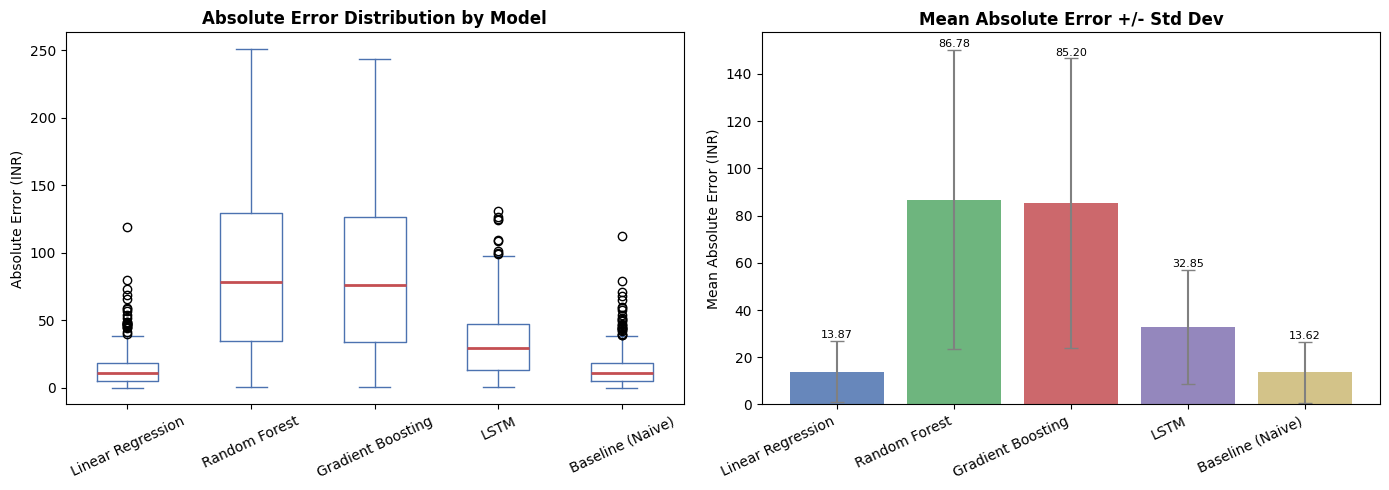

Error distribution plots saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
error_df.boxplot(
    ax=axes[0], rot=25, grid=False,
    boxprops=dict(color='#4C72B0'),
    medianprops=dict(color='#C44E52', linewidth=2),
    whiskerprops=dict(color='#4C72B0'),
    capprops=dict(color='#4C72B0')
)
axes[0].set_title('Absolute Error Distribution by Model', fontweight='bold')
axes[0].set_ylabel('Absolute Error (INR)')

# Mean +/- std bar chart
means  = error_df.mean()
stds   = error_df.std()
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

axes[1].bar(
    range(len(means)), means,
    yerr=stds, capsize=5,
    color=colors, alpha=0.85, ecolor='gray'
)
axes[1].set_xticks(range(len(means)))
axes[1].set_xticklabels(error_df.columns, rotation=25, ha='right')
axes[1].set_title('Mean Absolute Error +/- Std Dev', fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error (INR)')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(
        i, m + s + 0.3, f'{m:.2f}',
        ha='center', va='bottom', fontsize=8
    )

plt.tight_layout()
plt.savefig(
    'stock_datasets/statistical_analysis_plots.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Error distribution plots saved.')

## STEP 10 — Pairwise p-value Heatmap

A heatmap of all pairwise Wilcoxon p-values makes it easy to identify which model pairs
are statistically distinguishable. Cells below the Bonferroni threshold (0.005) are the
significant ones.

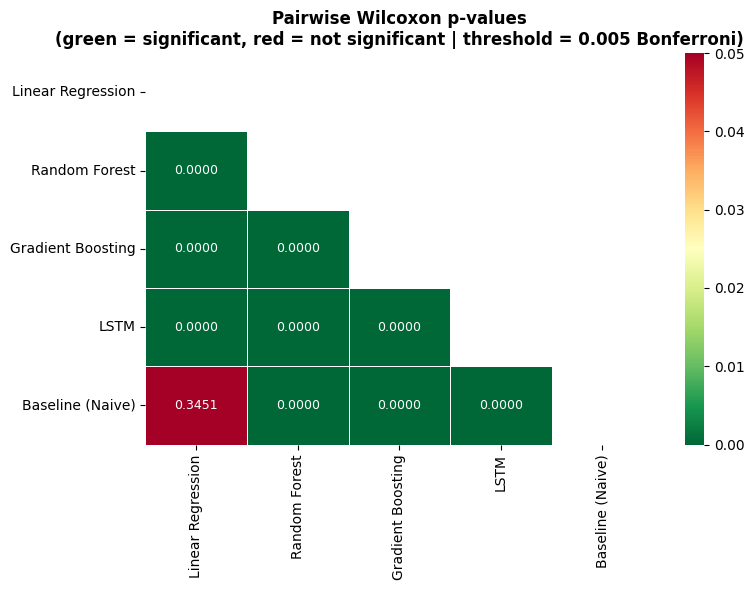

Pairwise p-value heatmap saved.


In [10]:
# Build p-value matrix
p_matrix = pd.DataFrame(
    np.ones((5, 5)),
    index=model_names, columns=model_names
)

for (n1, e1), (n2, e2) in combinations(
    zip(model_names, error_arrays), 2
):
    _, p = wilcoxon(e1, e2)
    p_matrix.loc[n1, n2] = p
    p_matrix.loc[n2, n1] = p

# Mask upper triangle and diagonal
mask = np.triu(np.ones_like(p_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    p_matrix,
    mask=mask,
    annot=True,
    fmt='.4f',
    cmap='RdYlGn_r',
    vmin=0, vmax=0.05,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title(
    'Pairwise Wilcoxon p-values\n'
    '(green = significant, red = not significant | threshold = 0.005 Bonferroni)',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    'stock_datasets/pairwise_pvalue_heatmap.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Pairwise p-value heatmap saved.')

## STEP 11 — Statistical Summary

The summary is built dynamically from the test results computed above, so it always
reflects the actual numbers rather than hardcoded values.

In [11]:
sep = '=' * 65

# Determine which models significantly beat the baseline (lower error + p<0.05)
beats = baseline_test_df[
    (baseline_test_df['wilcoxon_p'] < 0.05) &
    (baseline_test_df['mean_err'] < baseline_test_df['base_err'])
]['Model'].tolist()
worse = baseline_test_df[
    (baseline_test_df['wilcoxon_p'] < 0.05) &
    (baseline_test_df['mean_err'] > baseline_test_df['base_err'])
]['Model'].tolist()
nodiff = baseline_test_df[
    baseline_test_df['wilcoxon_p'] >= 0.05
]['Model'].tolist()

best_model = error_df.mean().idxmin()

lines = [
    sep,
    'STATISTICAL ANALYSIS SUMMARY',
    sep,
    '',
    '1. NORMALITY (Shapiro-Wilk)',
    '   All error distributions are non-normal (p < 0.05).',
    '   Non-parametric Wilcoxon tests are used for all comparisons.',
    '',
    '2. LEVENE TEST (Equal Variance)',
    '   Model error variances are significantly different (p < 0.05).',
    '   Further supports use of non-parametric tests.',
    '',
    '3. ONE-WAY ANOVA',
    '   F-test confirms a significant difference exists across the 5 models.',
    '   Pairwise testing is therefore justified.',
    '',
    '4. MODEL vs BASELINE (Naive)',
    f'   Lowest mean abs error overall : {best_model}',
    f'   Significantly BEATS baseline  : {beats if beats else "none"}',
    f'   Significantly WORSE than base : {worse if worse else "none"}',
    f'   No significant difference     : {nodiff if nodiff else "none"}',
    '',
    '5. INTERPRETATION',
    '   The tree models (Random Forest, Gradient Boosting) have large errors',
    '   because they cannot extrapolate beyond the training price range, while',
    '   the test period sits at higher price levels.',
    '   Linear Regression tracks the price closely but does not significantly',
    '   beat the naive "tomorrow = today" benchmark, which is consistent with',
    '   near-random next-day direction (~50% accuracy in evaluation).',
    sep
]

summary_text = '\n'.join(lines)
print(summary_text)

with open('stock_datasets/statistical_analysis_summary.txt', 'w') as f:
    f.write(summary_text)
print('\nSummary saved to stock_datasets/statistical_analysis_summary.txt')

STATISTICAL ANALYSIS SUMMARY

1. NORMALITY (Shapiro-Wilk)
   All error distributions are non-normal (p < 0.05).
   Non-parametric Wilcoxon tests are used for all comparisons.

2. LEVENE TEST (Equal Variance)
   Model error variances are significantly different (p < 0.05).
   Further supports use of non-parametric tests.

3. ONE-WAY ANOVA
   F-test confirms a significant difference exists across the 5 models.
   Pairwise testing is therefore justified.

4. MODEL vs BASELINE (Naive)
   Lowest mean abs error overall : Baseline (Naive)
   Significantly BEATS baseline  : none
   Significantly WORSE than base : ['Random Forest', 'Gradient Boosting', 'LSTM']
   No significant difference     : ['Linear Regression']

5. INTERPRETATION
   The tree models (Random Forest, Gradient Boosting) have large errors
   because they cannot extrapolate beyond the training price range, while
   the test period sits at higher price levels.
   Linear Regression tracks the price closely but does not significant